In [48]:
import torch
import geospaNN
import numpy as np
import time
import pandas as pd
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt

path = '../data/Output/'

In [49]:
def f1(X): return 10 * np.sin(np.pi * 2 * X)


sigma = 1
phi = 0.1
Lambda = 0.01
theta = torch.tensor([sigma, phi / np.sqrt(2), Lambda])

p = 1;
funXY = f1

n = 1000
nn = 20
batch_size = 50

torch.manual_seed(2025)
_, _, _, _, X = geospaNN.Simulation(n, p, nn, funXY, torch.tensor([1, 5, 0.01]), range=[0, 1])
X = X.reshape(-1,1)
X = (X - X.min())/(X.max() - X.min())
torch.manual_seed(2025)
_, _, coord, cov, corerr = geospaNN.Simulation(n, p, nn, funXY, theta, range=[0, 1])
Y = funXY(X).reshape(-1) + corerr

torch.manual_seed(2024)
np.random.seed(0)
data_train, data_val, data_test = geospaNN.split_data(X, Y, coord, neighbor_size=nn,
                                                      test_proportion=0.2)

In [50]:
torch.manual_seed(2025)
mlp_nn = torch.nn.Sequential(
    torch.nn.Linear(p, 5),
    torch.nn.ReLU(),
    torch.nn.Linear(5, 1)
)
trainer_nn = geospaNN.nn_train(mlp_nn, lr=0.01, min_delta=0.001)
training_log = trainer_nn.train(data_train, data_val, data_test)
theta0 = geospaNN.theta_update(mlp_nn(data_train.x).squeeze() - data_train.y, data_train.pos, neighbor_size=20)

INFO: Early stopping
End at epoch80
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 4.47407376 29.24566062  0.06124933]


In [51]:
torch.manual_seed(2025)
mlp_linear = torch.nn.Sequential(
    torch.nn.Linear(p, 1),
)
model_linear = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_linear, theta = torch.tensor(theta0))
trainer_linear = geospaNN.nngls_train(model_linear, lr=0.05, min_delta=0.001)
training_log = trainer_linear.train(data_train, data_val, data_test,
                                        Update_init=20, Update_step=5)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[2.34158402e+01 1.58407066e+01 1.00000000e-03]
to
[2.34158402e+01 1.58407066e+01 1.00000000e-03]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[2.22860964e+01 1.62666666e+01 1.00000000e-03]
to
[2.22860964e+01 1.62666666e+01 1.00000000e-03]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


...

Theta estimated as
[1.26010933e+01 2.27574114e+01 7.68111852e-03]
to
[1.26010933e+01 2.27574114e+01 7.68111852e-03]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[1.19462345e+01 2.35926069e+01 9.09695272e-03]
to
[1.19462345e+01 2.35926069e+01 9.09695272e-03]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[1.13419740e+01 2.44623873e+01 1.05276713e-02]
to
[1.13419740e+01 2.44623873e+01 1.05276713e-02]


In [52]:
torch.manual_seed(2025)
mlp_l1_n5 = torch.nn.Sequential(
    torch.nn.Linear(p, 5),
    torch.nn.ReLU(),
    torch.nn.Linear(5, 1)
)
nngls_l1_n5 = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_l1_n5, theta=torch.tensor(theta0))
trainer_l1_n5 = geospaNN.nngls_train(nngls_l1_n5, lr=0.05, min_delta=0.001)
training_log = trainer_l1_n5.train(data_train, data_val, data_test,
                                   Update_init=20, Update_step=5, seed = 2024)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 4.5434705  23.62171852  0.08103391]
to
[ 4.5434705  23.62171852  0.08103391]
INFO: Early stopping
End at epoch20


In [53]:
torch.manual_seed(2025)
mlp_l1_n20 = torch.nn.Sequential(
    torch.nn.Linear(p, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1)
)
nngls_l1_n20 = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_l1_n20, 
                              theta=torch.tensor(theta0))
trainer_l1_n20 = geospaNN.nngls_train(nngls_l1_n20, lr=0.05, min_delta=0.001)
training_log = trainer_l1_n20.train(data_train, data_val, data_test,
                                    Update_init=20, Update_step=5, seed = 2024)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 4.45809069 26.45606746  0.07502113]
to
[ 4.45809069 26.45606746  0.07502113]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 4.3886438  24.75460419  0.07979796]
to
[ 4.3886438  24.75460419  0.07979796]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


...

Theta estimated as
[ 0.52768732 17.72422353  0.53169948]
to
[ 0.52768732 17.72422353  0.53169948]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 0.58197303 15.2294767   0.36203706]
to
[ 0.58197303 15.2294767   0.36203706]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 0.43918984 17.19213505  0.50299676]
to
[ 0.43918984 17.19213505  0.50299676]


In [54]:
torch.manual_seed(2025)
mlp_l1_n50 = torch.nn.Sequential(
    torch.nn.Linear(p, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)
nngls_l1_n50 = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_l1_n50, 
                              theta=torch.tensor(theta0))
trainer_l1_n50 = geospaNN.nngls_train(nngls_l1_n50, lr=0.05, min_delta=0.001)
training_log = trainer_l1_n50.train(data_train, data_val, data_test,
                                    Update_init=20, Update_step=5, seed = 2024)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 3.59350358 26.67174391  0.07921286]
to
[ 3.59350358 26.67174391  0.07921286]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 2.89907985 20.87026897  0.10381284]
to
[ 2.89907985 20.87026897  0.10381284]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


...

Theta estimated as
[0.23368257 4.4756431  0.14363708]
to
[0.23368257 4.4756431  0.14363708]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.25668967 3.94063007 0.0909633 ]
to
[0.25668967 3.94063007 0.0909633 ]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.35416875 2.71922385 0.05090323]
to
[0.35416875 2.71922385 0.05090323]
INFO: Early stopping
End at epoch78


In [55]:
torch.manual_seed(2025)
mlp_l2_n5_2 = torch.nn.Sequential(
    torch.nn.Linear(p, 5),
    torch.nn.ReLU(),
    torch.nn.Linear(5, 2),
    torch.nn.ReLU(),
    torch.nn.Linear(2, 1)
)
nngls_l2_n5_2 = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_l2_n5_2, theta=torch.tensor(theta0))
trainer_l2_n5_2 = geospaNN.nngls_train(nngls_l2_n5_2, lr=0.05, min_delta=0.001)
training_log = trainer_l2_n5_2.train(data_train, data_val, data_test,
                                     Update_init=20, Update_step=5, seed = 2024)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 1.28565231 28.56514115  0.24717448]
to
[ 1.28565231 28.56514115  0.24717448]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 1.08493459 19.52539802  0.28557687]
to
[ 1.08493459 19.52539802  0.28557687]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 0.98450559 16.12540983  0.31283296]
to
[ 0.98450559 16.12540983  0.31283296]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[ 0.96334335 16.57307228  0.31105348]
to
[ 0.96334335 16.57307228  0.31105348]
INFO: Early stopping
End at epoch35


In [56]:
torch.manual_seed(2026)
mlp_l2_n50_20 = torch.nn.Sequential(
    torch.nn.Linear(p, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1)
)
nngls_l2_n50_20 = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_l2_n50_20, theta=torch.tensor(theta0))
trainer_l2_n50_20 = geospaNN.nngls_train(nngls_l2_n50_20, lr=0.05, min_delta=0.001)
training_log = trainer_l2_n50_20.train(data_train, data_val, data_test,
                                       Update_init=20, Update_step=5, seed = 2024)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.7069454  4.14446019 0.05395588]
to
[0.7069454  4.14446019 0.05395588]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.60378483 7.69398412 0.07367244]
to
[0.60378483 7.69398412 0.07367244]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


...

Theta estimated as
[0.41436375 1.92810822 0.0191417 ]
to
[0.41436375 1.92810822 0.0191417 ]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.3242643  2.44549934 0.02680307]
to
[0.3242643  2.44549934 0.02680307]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.30328186 2.74172082 0.02724104]
to
[0.30328186 2.74172082 0.02724104]
INFO: Early stopping
End at epoch52


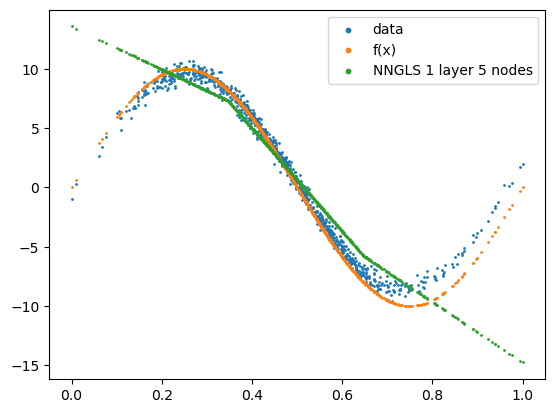

In [57]:
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
plt.scatter(X.detach().numpy(), mlp_l1_n5(X).detach().numpy(), s=1, label='NNGLS 1 layer 5 nodes')
#plt.scatter(X.detach().numpy(), mlp_l1_n20(X).detach().numpy(), s=1, label='NNGLS 1 layer 20 nodes')
#plt.scatter(X.detach().numpy(), mlp_l1_n50(X).detach().numpy(), s=1, label='NNGLS 1 layer 50 nodes')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'l1n5.png')

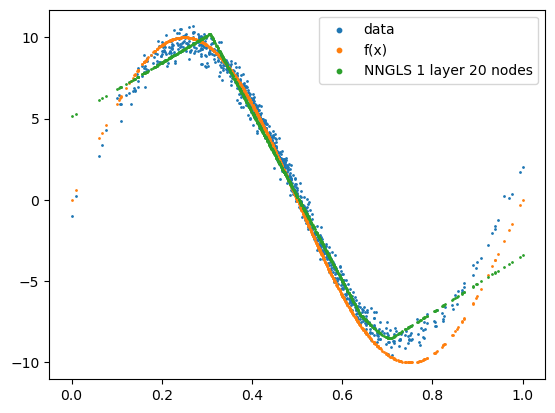

In [58]:
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
#plt.scatter(X.detach().numpy(), mlp_l1_n5(X).detach().numpy(), s=1, label='NNGLS 1 layer 5 nodes')
plt.scatter(X.detach().numpy(), mlp_l1_n20(X).detach().numpy(), s=1, label='NNGLS 1 layer 20 nodes')
#plt.scatter(X.detach().numpy(), mlp_l1_n50(X).detach().numpy(), s=1, label='NNGLS 1 layer 50 nodes')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'l1n20.png')

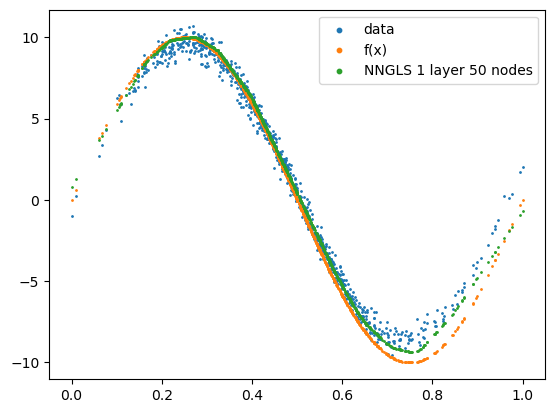

In [59]:
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
#plt.scatter(X.detach().numpy(), mlp_l1_n5(X).detach().numpy(), s=1, label='NNGLS 1 layer 5 nodes')
#plt.scatter(X.detach().numpy(), mlp_l1_n20(X).detach().numpy(), s=1, label='NNGLS 1 layer 20 nodes')
plt.scatter(X.detach().numpy(), mlp_l1_n50(X).detach().numpy(), s=1, label='NNGLS 1 layer 50 nodes')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'l1n50.png')

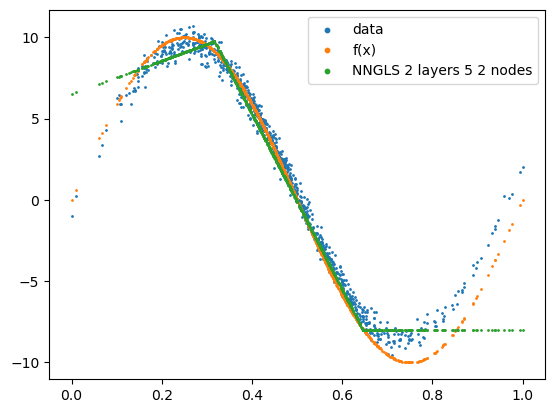

In [60]:
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
plt.scatter(X.detach().numpy(), mlp_l2_n5_2(X).detach().numpy(), s=1, label='NNGLS 2 layers 5 2 nodes')
#plt.scatter(X.detach().numpy(), mlp_l2_n50_20(X).detach().numpy(), s=1, label='NNGLS 2 layers 50 20 nodes')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'l2n5_2.png')

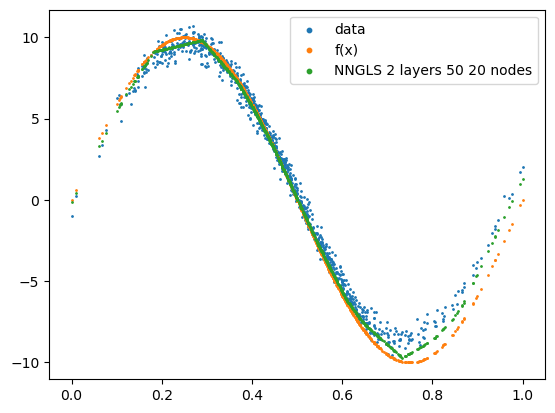

In [61]:
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
#plt.scatter(X.detach().numpy(), mlp_l2_n5_2(X).detach().numpy(), s=1, label='NNGLS 2 layers 5 2 nodes')
plt.scatter(X.detach().numpy(), mlp_l2_n50_20(X).detach().numpy(), s=1, label='NNGLS 2 layers 50 20 nodes')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.savefig(path + 'l2n50_20.png')

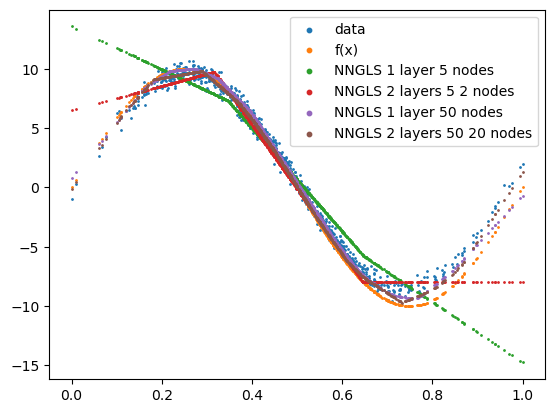

In [62]:
plt.clf()
plt.scatter(X.detach().numpy(), Y.detach().numpy(), s=1, label='data')
plt.scatter(X.detach().numpy(), funXY(X.detach().numpy()), s=1, label='f(x)')
plt.scatter(X.detach().numpy(), mlp_l1_n5(X).detach().numpy(), s=1, label='NNGLS 1 layer 5 nodes')
plt.scatter(X.detach().numpy(), mlp_l2_n5_2(X).detach().numpy(), s=1, label='NNGLS 2 layers 5 2 nodes')
plt.scatter(X.detach().numpy(), mlp_l1_n50(X).detach().numpy(), s=1, label='NNGLS 1 layer 50 nodes')
plt.scatter(X.detach().numpy(), mlp_l2_n50_20(X).detach().numpy(), s=1, label='NNGLS 2 layers 50 20 nodes')
lgnd = plt.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
plt.show()